In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

(-1.0, 1.0)

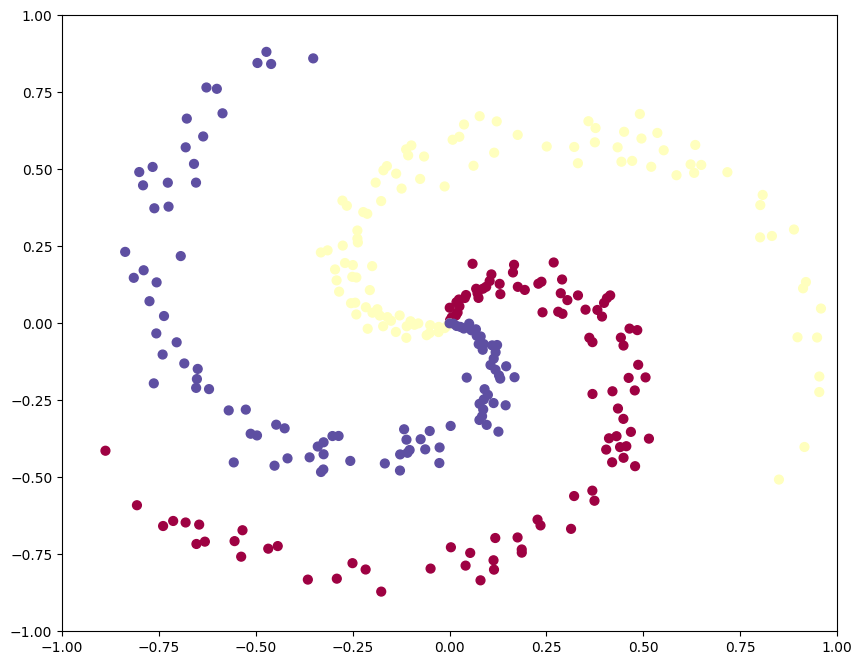

In [2]:
#generate random data -- not linearly separable
np.random.seed(0)
N = 100  # number of points per class
D = 2    # dimensionality
K = 3    # number of classes
X_np = np.zeros((N*K, D))
y_np = np.zeros(N*K, dtype='uint8')
for j in range(K):
    ix = range(N*j, N*(j+1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*0.2
    X_np[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y_np[ix] = j

# Convert to PyTorch tensors
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)

fig = plt.figure()
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, s=40, cmap=plt.cm.Spectral)
plt.xlim([-1,1])
plt.ylim([-1,1])


The sigmoid function "squashes" inputs to lie between 0 and 1. Unfortunately, this means that for inputs with sigmoid output close to 0 or 1, the gradient with respect to those inputs are close to zero. This leads to the phenomenon of vanishing gradients, where gradients drop close to zero, and the net does not learn well.


On the other hand, the relu function (max(0, x)) does not saturate with input size. Plot these functions to gain intution.

Let's try and see now how the two kinds of nonlinearities change deep neural net training in practice. Below, we build a very simple neural net with three layers (two hidden layers), for which you can swap out ReLU/ sigmoid nonlinearities.

In [5]:
class ThreeLayerNet(nn.Module):
    def __init__(self, D, h, h2, K, nonlinearity='RELU'):
        super().__init__()
        self.fc1 = nn.Linear(D, h)
        self.fc2 = nn.Linear(h, h2)
        self.fc3 = nn.Linear(h2, K)
        self.nonlinearity = nonlinearity

    def forward(self, x):
        act = torch.relu if self.nonlinearity == 'RELU' else torch.sigmoid
        x = act(self.fc1(x))
        x = act(self.fc2(x))
        x = self.fc3(x)
        return x

This is a 3-layer architecture

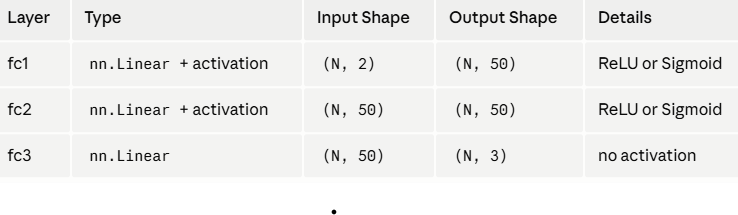

* Input: 2D points (x, y) — D=2
* Two hidden layers of size h=h2=50
* Output: 3 raw scores (one per class) — K=3

Loss: CrossEntropyLoss (applies Softmax internally, so no activation on fc3)

In [3]:
# build, initialize, train and evaluate ThreeLayerNet
def train_net(nonlinearity, X, y, h=50, h2=50, step_size=1e-1, reg=1e-3, iters=50000):
    D, K = X.shape[1], int(y.max().item()) + 1
    torch.manual_seed(0)
    
    #Step 1: build model; D= 2 and K = 3 classes
    model = ThreeLayerNet(D, h, h2, K, nonlinearity)

    # Step 2: initialize weights
    for layer in [model.fc1, model.fc2, model.fc3]:
        nn.init.normal_(layer.weight, std=0.1)
        nn.init.zeros_(layer.bias)

    # Step 3 Set up optimizer and loss
    optimizer = optim.SGD(model.parameters(), lr=step_size, weight_decay=reg)
    criterion = nn.CrossEntropyLoss()

    grad_W1_norms, grad_W2_norms = [], []
    # 4. Training loop (50,000 iterations)
    for i in range(iters):
        optimizer.zero_grad() # — clear gradients from previous step
        scores = model(X) # — forward pass, get class scores (300, 3)
        loss = criterion(scores, y) #  compute cross-entropy loss
        loss.backward() # compute gradients

        # Record gradient magnitudes for fc1 and fc2:
        # This is the mean absolute gradient — used later to plot vanishing gradients.
        grad_W1_norms.append(model.fc1.weight.grad.abs().sum().item() /
                             model.fc1.weight.grad.numel())
        grad_W2_norms.append(model.fc2.weight.grad.abs().sum().item() /
                             model.fc2.weight.grad.numel())

        # update weights
        optimizer.step()

        if i % 1000 == 0:
            print(f'iteration {i}: loss {loss.item():.6f}')
   # Step 5: evaluate accuracy
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
        acc = (preds == y).float().mean().item()
    print(f'training accuracy: {acc:.2f}')

    # Returns: the trained model and the two gradient norm arrays, which are later plotted to visualize the vanishing gradient problem
    return model, grad_W1_norms, grad_W2_norms

### Train net with sigmoid nonlinearity first

In [6]:
sigm_model, sigm_array_1, sigm_array_2 = train_net('SIGM', X, y, step_size=1e-1, reg=1e-3)

iteration 0: loss 1.140047
iteration 1000: loss 1.089689
iteration 2000: loss 0.994874
iteration 3000: loss 0.796685
iteration 4000: loss 0.772786
iteration 5000: loss 0.767310
iteration 6000: loss 0.761689
iteration 7000: loss 0.754927
iteration 8000: loss 0.745605
iteration 9000: loss 0.729062
iteration 10000: loss 0.689696
iteration 11000: loss 0.623838
iteration 12000: loss 0.570091
iteration 13000: loss 0.530754
iteration 14000: loss 0.494788
iteration 15000: loss 0.458386
iteration 16000: loss 0.419167
iteration 17000: loss 0.377284
iteration 18000: loss 0.337190
iteration 19000: loss 0.302574
iteration 20000: loss 0.274786
iteration 21000: loss 0.253518
iteration 22000: loss 0.237698
iteration 23000: loss 0.226168
iteration 24000: loss 0.217744
iteration 25000: loss 0.211429
iteration 26000: loss 0.206511
iteration 27000: loss 0.202527
iteration 28000: loss 0.199177
iteration 29000: loss 0.196272
iteration 30000: loss 0.193690
iteration 31000: loss 0.191356
iteration 32000: loss

### Now train net with ReLU nonlinearity

In [7]:
relu_model, relu_array_1, relu_array_2 = train_net('RELU', X, y, step_size=1e-1, reg=1e-3)

iteration 0: loss 1.101967
iteration 1000: loss 0.241417
iteration 2000: loss 0.089753
iteration 3000: loss 0.062517
iteration 4000: loss 0.053092
iteration 5000: loss 0.048538
iteration 6000: loss 0.046040
iteration 7000: loss 0.044617
iteration 8000: loss 0.043730
iteration 9000: loss 0.043145
iteration 10000: loss 0.042734
iteration 11000: loss 0.042433
iteration 12000: loss 0.042183
iteration 13000: loss 0.041957
iteration 14000: loss 0.041770
iteration 15000: loss 0.041615
iteration 16000: loss 0.041468
iteration 17000: loss 0.041337
iteration 18000: loss 0.041217
iteration 19000: loss 0.041118
iteration 20000: loss 0.041036
iteration 21000: loss 0.040967
iteration 22000: loss 0.040909
iteration 23000: loss 0.040861
iteration 24000: loss 0.040814
iteration 25000: loss 0.040754
iteration 26000: loss 0.040693
iteration 27000: loss 0.040614
iteration 28000: loss 0.040534
iteration 29000: loss 0.040456
iteration 30000: loss 0.040378
iteration 31000: loss 0.040309
iteration 32000: loss


# The Vanishing Gradient Issue

We can use the sum of the magnitude of gradients for the weights between hidden layers as a cheap heuristic to measure speed of learning (you can also use the magnitude of gradients for each neuron in the hidden layer here). Intuitevely, when the magnitude of the gradients of the weight vectors or of each neuron are large, the net is learning faster. (NOTE: For our net, each hidden layer has the same number of neurons. If you want to play around with this, make sure to adjust the heuristic to account for the number of neurons in the layer).

Purpose of the experiment: Track gradient magnitudes at fc1 and fc2 during training to show that Sigmoid causes vanishing gradients in earlier layers (gradients shrink as they backpropagate), while ReLU does not — explaining why ReLU reaches lower loss much faster (0.04 vs 0.17 after 50k iterations).

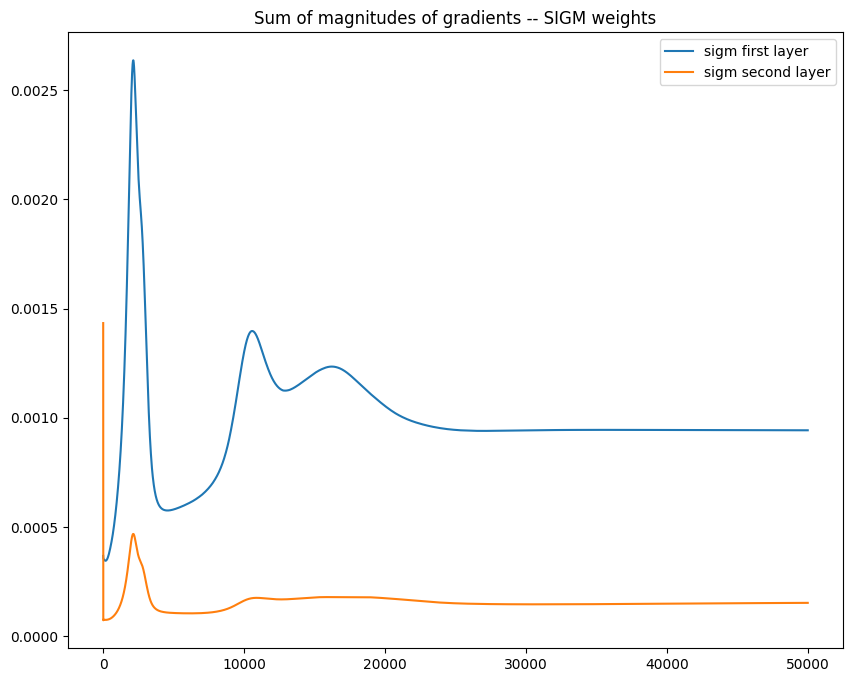

In [24]:
plt.plot(sigm_array_1)
plt.plot(sigm_array_2)
plt.title('Sum of magnitudes of gradients -- SIGM weights')
plt.legend(('sigm first layer', 'sigm second layer'))

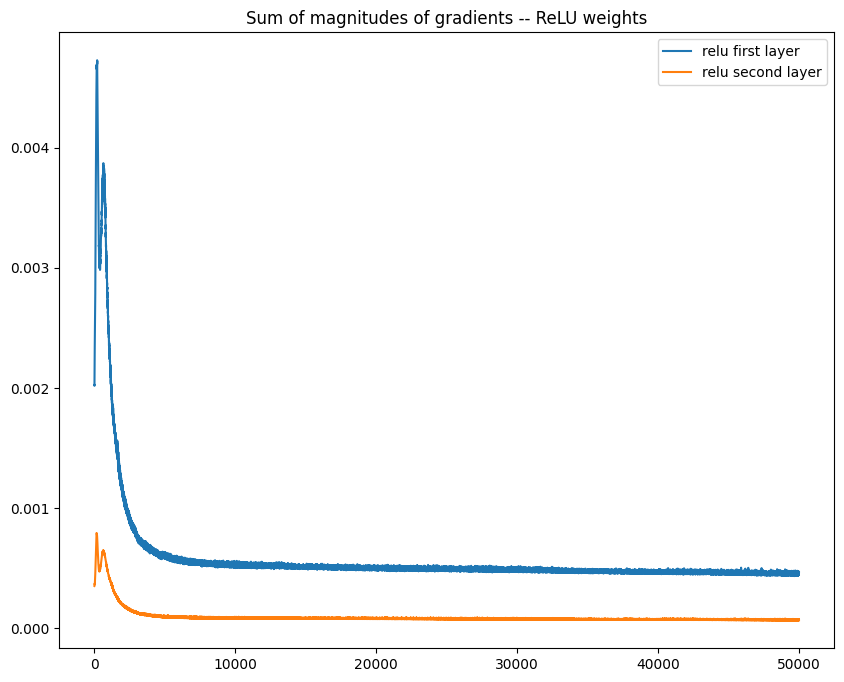

In [25]:
plt.plot(relu_array_1)
plt.plot(relu_array_2)
plt.title('Sum of magnitudes of gradients -- ReLU weights')
plt.legend(('relu first layer', 'relu second layer'))

For Sigmoid:

Gradients in fc1 (first layer) are much smaller than in fc2 (second layer)
Earlier layers learn slower because gradients shrink as they backpropagate through each Sigmoid
For ReLU:

Gradients stay large in both fc1 and fc2
Both layers learn at a similar speed throughout training

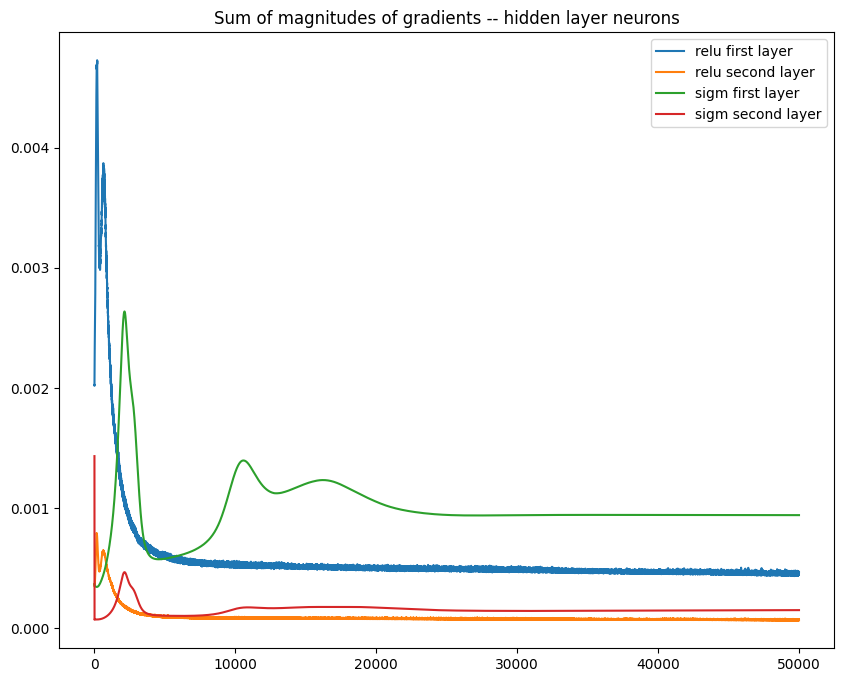

In [26]:
# Overlaying the two plots to compare
plt.plot(relu_array_1)
plt.plot(relu_array_2)
plt.plot(sigm_array_1)
plt.plot(sigm_array_2)
plt.title('Sum of magnitudes of gradients -- hidden layer neurons')
plt.legend(('relu first layer', 'relu second layer', 'sigm first layer', 'sigm second layer'))


### Feel free to play around with this notebook to gain intuition. Things you might want to try:

* Adding additional layers to the nets and seeing how early layers continue to train slowly for the sigmoid net
* Experiment with hyperparameter tuning for the nets -- changing regularization and gradient descent step size
* Experiment with different nonlinearities -- Leaky ReLU, Maxout. How quickly do different layers learn now?
  
We can see how well each classifier does in terms of distinguishing the toy data classes. As expected, since the ReLU net trains faster, for a set number of epochs it performs better compared to the sigmoid net.

Text(0.5, 1.0, 'Decision boundary -- Sigmoid')

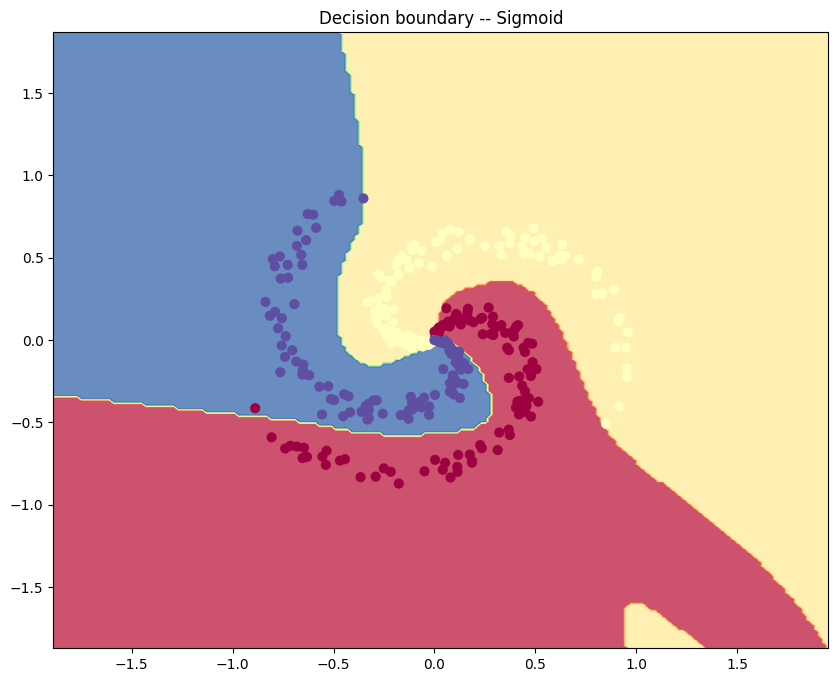

In [27]:
# plot the classifiers -- SIGMOID
h_step = 0.02
x_min, x_max = X_np[:, 0].min() - 1, X_np[:, 0].max() + 1
y_min, y_max = X_np[:, 1].min() - 1, X_np[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h_step),
                     np.arange(y_min, y_max, h_step))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = sigm_model(grid).argmax(dim=1).numpy()
Z = Z.reshape(xx.shape)
fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Decision boundary -- Sigmoid')

Text(0.5, 1.0, 'Decision boundary -- ReLU')

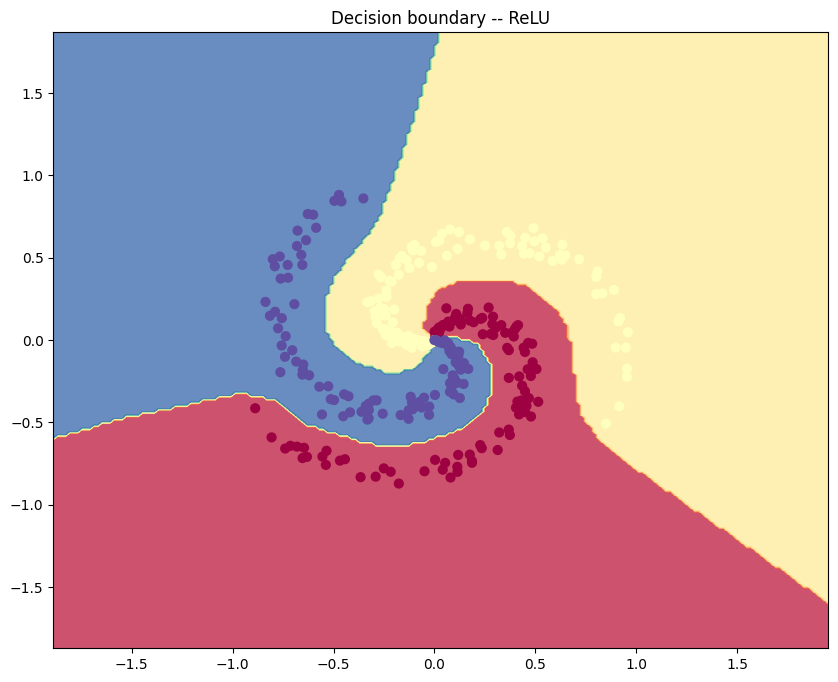

In [28]:
# plot the classifiers -- RELU
h_step = 0.02
x_min, x_max = X_np[:, 0].min() - 1, X_np[:, 0].max() + 1
y_min, y_max = X_np[:, 1].min() - 1, X_np[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h_step),
                     np.arange(y_min, y_max, h_step))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = relu_model(grid).argmax(dim=1).numpy()
Z = Z.reshape(xx.shape)
fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Decision boundary -- ReLU')